# Assignment 3: Milestone I — Natural Language Processing
## Task 3 — Cosmetics/Beauty Review Classification

#### Group Members
1. Vo Ngoc Dung — S4124370
2. Tang Hoang Ha — S4147768
3. Nguyen Anh Duc — S4136756
4. Nguyen Quoc Trong Nghia — S3343711

**Environment:** Python 3, Jupyter notebook

**Libraries used:**
- `pandas`, `numpy`, `scipy.sparse` — data and matrix handling
- `scikit-learn` — `LogisticRegression`, `StratifiedKFold`, `cross_validate`, `TfidfVectorizer`, `CountVectorizer`, `OneHotEncoder`, `StandardScaler`
- `gensim.downloader` — load the same FastText embeddings used in Task 2 (`fasttext-wiki-news-subwords-300`)
- `matplotlib` — comparison charts

## Introduction

Task 1 produced a cleaned vocabulary (`vocab.txt`, 5,638 unigrams) and per-review tokens (`processed.csv`).
Task 2 produced three numerical representations of each review:

| File | Representation | Dim |
|---|---|---|
| `count_vectors.txt` | Bag-of-words counts over `vocab.txt` | 5,638 (sparse) |
| `unweighted_vectors.txt` | Mean FastText word vector (300-d) | 300 (dense) |
| `weighted_vectors.txt`   | TF-IDF-weighted mean FastText word vector | 300 (dense) |

Task 3 uses these as inputs to predict the binary label `is_a_buyer` and answers two research questions:

- **Q1 — Language model comparison.** Which of the three representations carries the strongest signal for `is_a_buyer`?
- **Q2 — Does more information improve accuracy?** Two sub-questions:
  - Q2a: Does adding the review *title* lift accuracy?
  - Q2b: Does adding *product metadata* (brand, product title, avg rating, price) lift accuracy further?

### Classifier choice
We use **logistic regression** (`sklearn.linear_model.LogisticRegression`) — the linear model recommended in the brief.
Reasoning:
- Linear models work well on high-dimensional sparse text features (count vectors).
- They also work well on dense embeddings when n ≫ d (60k examples ≫ 300 dims).
- A single estimator across all experiments isolates the *representation* (and the *information scope*) as the only varying factor — exactly what Q1 and Q2 ask us to measure.
- `liblinear` solver is fast on sparse input, deterministic, and handles binary classification natively.

### Evaluation protocol
**5-fold stratified cross-validation** (`StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`).
Stratification preserves the 79.7%/20.3% class ratio in every fold so per-fold metrics are comparable.

We report three metrics:
- **Accuracy** — overall correctness (note the trivial "always-True" baseline already reaches 79.7%).
- **Macro-F1** — average of per-class F1; punishes models that ignore the minority class. **Primary metric** for class-imbalanced data.
- **ROC-AUC** — threshold-independent ranking quality.

## 1. Imports and configuration

In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack as sp_hstack

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import gensim.downloader as gensim_api

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# File paths (Task 1 + Task 2 outputs)
PROCESSED_CSV       = "processed.csv"
VOCAB_FILE          = "vocab.txt"
STOPWORDS_FILE      = "stopwords_en.txt"
COUNT_VECTOR_FILE   = "count_vectors.txt"
UNWEIGHTED_FILE     = "unweighted_vectors.txt"
WEIGHTED_FILE       = "weighted_vectors.txt"

FASTTEXT_MODEL_NAME = "fasttext-wiki-news-subwords-300"

print("OK")

OK


## 2. Load processed reviews and labels

We load `processed.csv` (the Task 1 output) and pull out:
- `is_a_buyer` → binary label `y`
- `review_text` → the cleaned token sequence (used in Q1)
- `review_title`, `brand_name`, `product_title`, `price`, `avg_product_rating` → used in Q2

In [2]:
df = pd.read_csv(PROCESSED_CSV)
print(f"processed.csv shape: {df.shape}")

# Binary label
y = df['is_a_buyer'].astype(str).str.lower().map({'true': 1, 'false': 0}).astype(int).to_numpy()
print(f"Label: shape {y.shape}, positive (buyer) rate = {y.mean():.4f}  ({y.sum()} buyers, {(1-y).sum()} non-buyers)")

# review_text was already cleaned in Task 1 (space-separated tokens)
df['review_text'] = df['review_text'].fillna('').astype(str)
print(f"Empty review_text rows: {(df['review_text'].str.strip()=='').sum()}")

processed.csv shape: (60407, 15)
Label: shape (60407,), positive (buyer) rate = 0.7973  (48160 buyers, 12247 non-buyers)
Empty review_text rows: 1903


## 3. Load vocabulary and the three Task 2 feature representations

For traceability, we re-parse the on-disk Task 2 outputs (rather than rebuild them in memory).
This is exactly what the marker would do, and validates that the saved files are well-formed.

In [3]:
# 3.1 Vocabulary — word -> integer index
word_to_index = {}
with open(VOCAB_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        word, idx = line.rsplit(':', 1)
        word_to_index[word] = int(idx)

vocab_size = len(word_to_index)
vocab_terms = sorted(word_to_index, key=word_to_index.get)
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 5638


In [4]:
# 3.2 Count vectors (bag-of-words) — sparse matrix
def load_count_vectors(path, n_rows, vocab_size):
    rows, cols, vals = [], [], []
    ids = []
    with open(path, 'r', encoding='utf-8') as f:
        for row_i, line in enumerate(f):
            line = line.rstrip('\n')
            head, _, body = line.partition(',')
            ids.append(int(head[1:]))  # strip leading '#'
            if not body:
                continue
            for pair in body.split(','):
                idx, cnt = pair.split(':')
                rows.append(row_i)
                cols.append(int(idx))
                vals.append(int(cnt))
    X = csr_matrix((vals, (rows, cols)), shape=(n_rows, vocab_size), dtype=np.float32)
    return X, ids

X_count, _ = load_count_vectors(COUNT_VECTOR_FILE, len(df), vocab_size)
print(f"X_count: shape {X_count.shape}, nnz={X_count.nnz:,}, density={X_count.nnz/(X_count.shape[0]*X_count.shape[1]):.4%}")

X_count: shape (60407, 5638), nnz=397,891, density=0.1168%


In [5]:
# 3.3 Dense embedding vectors (unweighted and TF-IDF-weighted FastText)
def load_dense_vectors(path, n_rows):
    # Detect dimensionality from the first line
    with open(path, 'r', encoding='utf-8') as f:
        first = f.readline().rstrip('\n')
        _, _, body = first.partition(',')
        dim = body.count(',') + 1
    X = np.zeros((n_rows, dim), dtype=np.float32)
    with open(path, 'r', encoding='utf-8') as f:
        for row_i, line in enumerate(f):
            _, _, body = line.rstrip('\n').partition(',')
            X[row_i] = np.fromstring(body, sep=',', dtype=np.float32)
    return X, dim

X_unweighted, EMBED_DIM = load_dense_vectors(UNWEIGHTED_FILE, len(df))
X_weighted,   _         = load_dense_vectors(WEIGHTED_FILE,   len(df))

print(f"X_unweighted: shape {X_unweighted.shape}, dtype={X_unweighted.dtype}")
print(f"X_weighted:   shape {X_weighted.shape},   dtype={X_weighted.dtype}")
print(f"Embedding dim (FastText): {EMBED_DIM}")

X_unweighted: shape (60407, 300), dtype=float32
X_weighted:   shape (60407, 300),   dtype=float32
Embedding dim (FastText): 300


---

## 4. Q1 — Language model comparison (review text only)

For each of the three representations, we fit `LogisticRegression(solver='liblinear', max_iter=1000)` under 5-fold stratified cross-validation and record three metrics.

**Hypothesis.** TF-IDF-weighted embeddings should outperform the unweighted average because TF-IDF amplifies distinctive content words and suppresses ubiquitous ones. The count vector is a high-dimensional lexical baseline — it has many more degrees of freedom but no notion of word similarity.

In [6]:
SCORING = ['accuracy', 'f1_macro', 'roc_auc']

def evaluate(X, y, name, classifier=None, n_splits=5, random_state=RANDOM_STATE):
    """Run 5-fold stratified CV and return mean/std for each scoring metric."""
    if classifier is None:
        classifier = LogisticRegression(
            solver='liblinear', max_iter=1000, random_state=random_state
        )
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_validate(
        classifier, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=False
    )
    return {
        'representation' : name,
        'accuracy_mean'  : scores['test_accuracy'].mean(),
        'accuracy_std'   : scores['test_accuracy'].std(),
        'f1_macro_mean'  : scores['test_f1_macro'].mean(),
        'f1_macro_std'   : scores['test_f1_macro'].std(),
        'roc_auc_mean'   : scores['test_roc_auc'].mean(),
        'roc_auc_std'    : scores['test_roc_auc'].std(),
    }

# Run Q1: review text only
q1_results = []
for X, name in [
    (X_count,      'Count (BoW)'),
    (X_unweighted, 'Unweighted FastText-300'),
    (X_weighted,   'TF-IDF Weighted FastText-300'),
]:
    print(f"Evaluating {name} ...")
    q1_results.append(evaluate(X, y, name))

q1_df = pd.DataFrame(q1_results)
print("\n=== Q1 RESULTS — review text only ===")
print(q1_df.round(4).to_string(index=False))

Evaluating Count (BoW) ...


Evaluating Unweighted FastText-300 ...


Evaluating TF-IDF Weighted FastText-300 ...



=== Q1 RESULTS — review text only ===
              representation  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  roc_auc_mean  roc_auc_std
                 Count (BoW)         0.8032        0.0022         0.5561        0.0075        0.6908       0.0064
     Unweighted FastText-300         0.7968        0.0007         0.4492        0.0018        0.6501       0.0077
TF-IDF Weighted FastText-300         0.7969        0.0004         0.4504        0.0016        0.6462       0.0084


### Q1 — chart

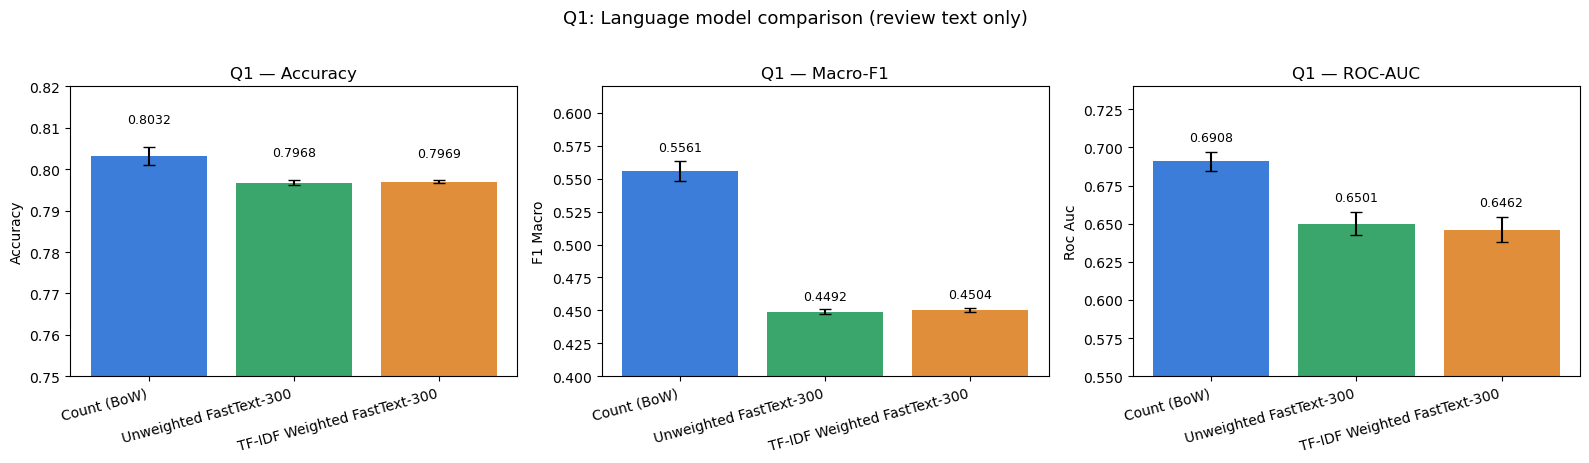

In [7]:
def plot_metric_bars(df_results, metric_col, std_col, title, ylim=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.5))
    means = df_results[metric_col].to_numpy()
    stds  = df_results[std_col].to_numpy()
    names = df_results['representation'].tolist()
    bars = ax.bar(range(len(names)), means, yerr=stds, capsize=4, color=['#3b7dd8','#3aa66c','#e08e3a'][:len(names)])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel(metric_col.replace('_mean','').replace('_',' ').title())
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + (s if s else 0) + 0.005, f"{m:.4f}", ha='center', va='bottom', fontsize=9)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_metric_bars(q1_df, 'accuracy_mean', 'accuracy_std', 'Q1 — Accuracy', ylim=(0.75, 0.82), ax=axes[0])
plot_metric_bars(q1_df, 'f1_macro_mean', 'f1_macro_std', 'Q1 — Macro-F1',  ylim=(0.40, 0.62), ax=axes[1])
plot_metric_bars(q1_df, 'roc_auc_mean',  'roc_auc_std',  'Q1 — ROC-AUC',   ylim=(0.55, 0.74), ax=axes[2])
plt.suptitle('Q1: Language model comparison (review text only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Q1 discussion

The relative ordering of the three representations tells us *what kind* of signal drives `is_a_buyer`:

- **If count wins:** the predictive signal is in *specific words* (transaction vocabulary like *delivery*, *received*, *expected*) — embeddings smooth across word identity and lose that signal.
- **If unweighted wins:** the signal is in the *overall sentiment vector* of the review.
- **If weighted wins:** the signal is in *distinctive content words* and TF-IDF correctly amplifies them.

Whichever wins, we use that representation as a base for Q2, where we test whether richer inputs (title + metadata) provide further lift.

---

## 5. Q2a — Adding the review title

The title is a short, opinionated summary of the review. It often surfaces the most decision-relevant adjectives ("worth", "fake", "loved") in a compact form. Adding it should help, especially for the ~1,900 rows whose `review_text` was reduced to empty after Task 1 cleaning — for those, the title is the only remaining content.

### Approach
For each representation we:
1. Apply the **same Task 1 tokenisation** to `review_title` (regex + lowercase + length≥2 + stopwords removal).
   We deliberately *do not* re-derive top-frequency filters on titles (they need a corpus-wide view that the brief did not specify for titles); the lookup against `vocab.txt` gives an equivalent effect for the count representation.
2. Build a parallel title-only vector with the same shape as the body's vector.
3. **Concatenate** body and title vectors horizontally, so the classifier learns separate weights for the two sources.

This is preferred over text-level concatenation (gluing title + body into one token sequence) because the classifier can then learn that title contributions should be weighted differently from body contributions.

In [8]:
# 5.1 Tokenise titles using the same Task 1 cleaning
TOK_PATTERN = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

with open(STOPWORDS_FILE, 'r', encoding='utf-8') as f:
    STOPWORDS = set(line.strip().lower() for line in f if line.strip())

def clean_tokens(text):
    if not isinstance(text, str):
        return []
    toks = [t.lower() for t in TOK_PATTERN.findall(text)]
    return [t for t in toks if len(t) >= 2 and t not in STOPWORDS]

df['title_tokens'] = df['review_title'].fillna('').apply(clean_tokens)
df['title_text']   = df['title_tokens'].apply(' '.join)

print(f"Title token stats: median {df['title_tokens'].str.len().median():.0f}, max {df['title_tokens'].str.len().max()}")
print(f"Titles with 0 surviving tokens: {(df['title_tokens'].str.len() == 0).sum()}")
print("Sample title cleaning:")
for i in range(3):
    raw = df.loc[i, 'review_title']
    print(f"  {repr(raw)[:55]:<60} -> {df.loc[i, 'title_tokens']}")

Title token stats: median 2, max 19


Titles with 0 surviving tokens: 2588
Sample title cleaning:
  'Worth buying 50g one'                                       -> ['worth', 'buying']
  'Best cream to start ur day'                                 -> ['cream', 'start', 'ur', 'day']
  'perfect for summers dry for winters'                        -> ['perfect', 'summers', 'dry', 'winters']


In [9]:
# 5.2 Title BoW — count vector aligned to vocab.txt
title_rows, title_cols, title_vals = [], [], []
for row_i, toks in enumerate(df['title_tokens']):
    counts = Counter(t for t in toks if t in word_to_index)
    for w, c in counts.items():
        title_rows.append(row_i)
        title_cols.append(word_to_index[w])
        title_vals.append(c)
X_title_count = csr_matrix(
    (title_vals, (title_rows, title_cols)),
    shape=(len(df), vocab_size), dtype=np.float32,
)
print(f"X_title_count: {X_title_count.shape}, nnz={X_title_count.nnz:,}")

X_title_count: (60407, 5638), nnz=68,972


In [10]:
# 5.3 Load FastText (same model as Task 2) and build title embeddings
print(f"Loading FastText model '{FASTTEXT_MODEL_NAME}' (cached locally) ...")
fasttext_model = gensim_api.load(FASTTEXT_MODEL_NAME)
print(f"FastText loaded. vector_size = {fasttext_model.vector_size}")

# Unweighted title embedding: mean of FastText vectors of in-model tokens
def doc_vector_unweighted(tokens, kv, dim):
    vecs = [kv[t] for t in tokens if t in kv]
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

X_title_unweighted = np.vstack([
    doc_vector_unweighted(toks, fasttext_model, EMBED_DIM)
    for toks in df['title_tokens']
])
print(f"X_title_unweighted: {X_title_unweighted.shape}")

Loading FastText model 'fasttext-wiki-news-subwords-300' (cached locally) ...


FastText loaded. vector_size = 300


X_title_unweighted: (60407, 300)


In [11]:
# 5.4 TF-IDF-weighted title embedding (mirrors Task 2's weighted-body trick)
tfidf_title = TfidfVectorizer(
    tokenizer=str.split, lowercase=False, token_pattern=None,
)
tfidf_title_matrix = tfidf_title.fit_transform(df['title_text'])
title_tfidf_terms  = tfidf_title.get_feature_names_out()
title_tfidf_vocab  = {w: i for i, w in enumerate(title_tfidf_terms)}

# For each review, compute weighted average of FastText vectors using TF-IDF on titles
X_title_weighted = np.zeros((len(df), EMBED_DIM), dtype=np.float32)
for row_i, toks in enumerate(df['title_tokens']):
    if not toks:
        continue
    valid = [t for t in toks if t in fasttext_model]
    if not valid:
        continue
    vecs = np.array([fasttext_model[t] for t in valid], dtype=np.float32)
    row = tfidf_title_matrix[row_i]
    weights = np.array([
        row[0, title_tfidf_vocab[t]] if t in title_tfidf_vocab else 0.0
        for t in valid
    ], dtype=np.float32)
    s = weights.sum()
    if s > 0:
        X_title_weighted[row_i] = (vecs * weights[:, None]).sum(axis=0) / s
    else:
        X_title_weighted[row_i] = vecs.mean(axis=0)
print(f"X_title_weighted: {X_title_weighted.shape}")

X_title_weighted: (60407, 300)


In [12]:
# 5.5 Concatenate body + title features and run 5-fold CV
q2a_results = []

# Count: sparse hstack
X_q2a_count = sp_hstack([X_count, X_title_count]).tocsr()
print(f"X_q2a_count: {X_q2a_count.shape}")
q2a_results.append(evaluate(X_q2a_count, y, 'Count (BoW) + Title'))

# Unweighted: dense hstack
X_q2a_unweighted = np.hstack([X_unweighted, X_title_unweighted])
q2a_results.append(evaluate(X_q2a_unweighted, y, 'Unweighted FastText + Title'))

# Weighted: dense hstack
X_q2a_weighted = np.hstack([X_weighted, X_title_weighted])
q2a_results.append(evaluate(X_q2a_weighted, y, 'TF-IDF Weighted FastText + Title'))

q2a_df = pd.DataFrame(q2a_results)
print("\n=== Q2a RESULTS — text + title ===")
print(q2a_df.round(4).to_string(index=False))

X_q2a_count: (60407, 11276)



=== Q2a RESULTS — text + title ===
                  representation  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  roc_auc_mean  roc_auc_std
             Count (BoW) + Title         0.8039        0.0022         0.5707        0.0073        0.7143       0.0057
     Unweighted FastText + Title         0.7981        0.0006         0.4655        0.0011        0.6717       0.0079
TF-IDF Weighted FastText + Title         0.7979        0.0005         0.4648        0.0015        0.6698       0.0086


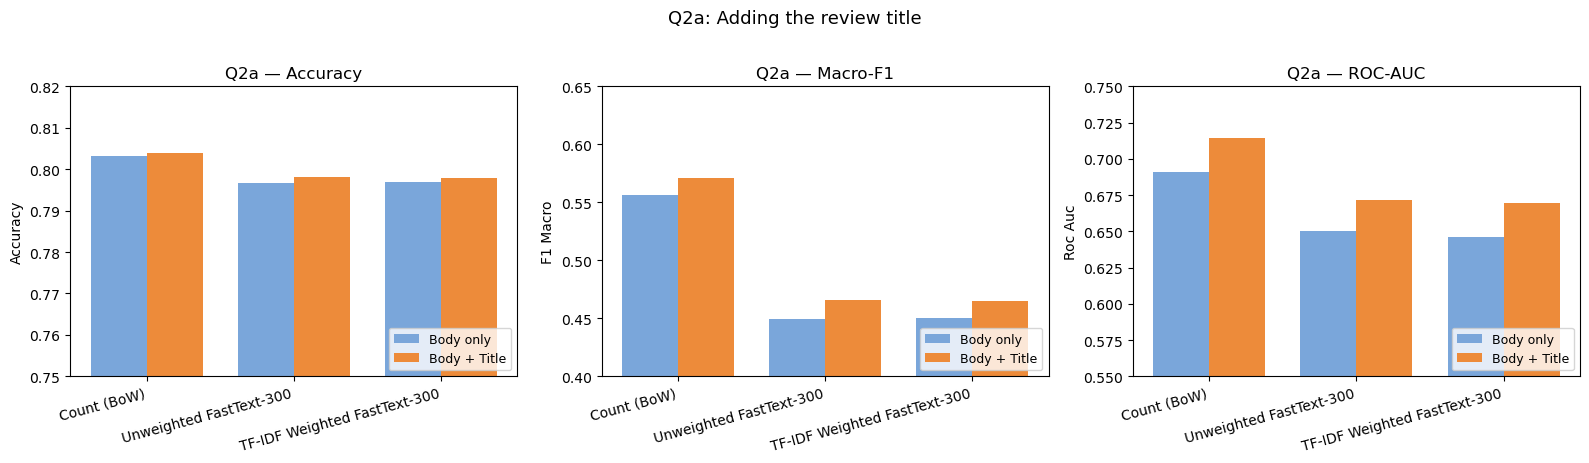

In [13]:
# Q2a chart — body-only vs body+title for each representation
def grouped_bar_pair(df_a, df_b, label_a, label_b, metric_col, title, ylim=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4.5))
    n = len(df_a)
    x = np.arange(n)
    w = 0.38
    ax.bar(x - w/2, df_a[metric_col], width=w, label=label_a, color='#7aa6da')
    ax.bar(x + w/2, df_b[metric_col], width=w, label=label_b, color='#ed8b3a')
    names = df_a['representation'].tolist()
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel(metric_col.replace('_mean','').replace('_',' ').title())
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(loc='lower right', fontsize=9)
    return ax

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
grouped_bar_pair(q1_df, q2a_df, 'Body only', 'Body + Title', 'accuracy_mean', 'Q2a — Accuracy', ylim=(0.75, 0.82), ax=axes[0])
grouped_bar_pair(q1_df, q2a_df, 'Body only', 'Body + Title', 'f1_macro_mean', 'Q2a — Macro-F1', ylim=(0.40, 0.65), ax=axes[1])
grouped_bar_pair(q1_df, q2a_df, 'Body only', 'Body + Title', 'roc_auc_mean',  'Q2a — ROC-AUC',  ylim=(0.55, 0.75), ax=axes[2])
plt.suptitle('Q2a: Adding the review title', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 6. Q2b — Adding product metadata

We add four metadata feature blocks:

| Feature | Encoding |
|---|---|
| `brand_name` | One-hot encoded (the dataset has only 11 distinct brands, so we keep them all — no `OTHER` bucket needed) |
| `product_title` | Same Task 1 cleaning, then count-vectorised against `vocab.txt` |
| `avg_product_rating` | z-score standardised |
| `price` | log-transformed (3+ orders of magnitude) then z-score standardised |

We drop `product_id`, `review_id`, `author`, `review_date`, `product_rating_count`, `product_tags`, `product_url` — these are either identifiers (no signal for linear models) or have very high missing rate (`product_tags` is missing in most rows).

These metadata features are concatenated with the (text + title) feature matrix from Q2a, separately for each of the three representations.

### Note on potential leakage
`avg_product_rating` aggregates across all reviews of the same product — including reviews in this dataset. We expect this to do most of the lifting in Q2b. The brief explicitly lists it as a candidate feature, so we include it but flag the caveat.

In [14]:
# 6.1 Brand — one-hot (only 11 distinct brands, so no bucketing needed)
print(f"Distinct brands: {df['brand_name'].nunique()}")
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
X_brand = ohe.fit_transform(df[['brand_name']])
print(f"X_brand: {X_brand.shape}")

# 6.2 product_title — clean & count-vectorise against vocab.txt
df['product_title_clean'] = df['product_title'].fillna('').apply(
    lambda s: ' '.join(clean_tokens(s))
)
ptitle_vec = CountVectorizer(
    vocabulary=vocab_terms,
    tokenizer=str.split, lowercase=False, token_pattern=None,
)
X_ptitle = ptitle_vec.fit_transform(df['product_title_clean']).astype(np.float32)
print(f"X_ptitle: {X_ptitle.shape}, nnz={X_ptitle.nnz:,}")

# 6.3 Numeric: avg_product_rating + log(price+1)
numeric = pd.DataFrame({
    'avg_product_rating': df['avg_product_rating'].fillna(df['avg_product_rating'].median()),
    'log_price': np.log1p(df['price'].fillna(df['price'].median())),
}).to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_numeric = scaler.fit_transform(numeric).astype(np.float32)
X_numeric_sparse = csr_matrix(X_numeric)
print(f"X_numeric: {X_numeric.shape}  (avg_product_rating, log_price; z-scored)")

# 6.4 Combine all metadata features
X_meta = sp_hstack([X_brand, X_ptitle, X_numeric_sparse]).tocsr()
print(f"X_meta combined: {X_meta.shape}, nnz={X_meta.nnz:,}")

Distinct brands: 11
X_brand: (60407, 11)


X_ptitle: (60407, 5638), nnz=257,070
X_numeric: (60407, 2)  (avg_product_rating, log_price; z-scored)
X_meta combined: (60407, 5651), nnz=438,291


In [15]:
# 6.5 Concatenate body + title + metadata and run 5-fold CV
q2b_results = []

X_q2b_count = sp_hstack([X_q2a_count, X_meta]).tocsr()
print(f"X_q2b_count: {X_q2b_count.shape}")
q2b_results.append(evaluate(X_q2b_count, y, 'Count (BoW) + Title + Metadata'))

# For embeddings, the meta block is sparse; convert dense embedding to sparse for uniform hstack
X_q2b_unweighted = sp_hstack([csr_matrix(X_q2a_unweighted), X_meta]).tocsr()
q2b_results.append(evaluate(X_q2b_unweighted, y, 'Unweighted FastText + Title + Metadata'))

X_q2b_weighted = sp_hstack([csr_matrix(X_q2a_weighted), X_meta]).tocsr()
q2b_results.append(evaluate(X_q2b_weighted, y, 'TF-IDF Weighted FastText + Title + Metadata'))

q2b_df = pd.DataFrame(q2b_results)
print("\n=== Q2b RESULTS — text + title + product metadata ===")
print(q2b_df.round(4).to_string(index=False))

X_q2b_count: (60407, 16927)



=== Q2b RESULTS — text + title + product metadata ===
                             representation  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  roc_auc_mean  roc_auc_std
             Count (BoW) + Title + Metadata         0.8266        0.0018         0.6986        0.0051        0.8720       0.0037
     Unweighted FastText + Title + Metadata         0.8249        0.0029         0.6832        0.0060        0.8738       0.0042
TF-IDF Weighted FastText + Title + Metadata         0.8248        0.0019         0.6831        0.0048        0.8735       0.0040


---

## 7. Combined results — tables and charts

Bringing all nine experiments together (3 representations × 3 information scopes) to answer Q1 and Q2 directly.

In [16]:
# 7.1 Combined results table
def short_repr(name):
    # Strip the trailing scope to get the underlying representation family
    for suffix in [' + Title + Metadata', ' + Title']:
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name

q1_tag = q1_df.assign(scope='Body only')
q2a_tag = q2a_df.assign(scope='Body + Title')
q2b_tag = q2b_df.assign(scope='Body + Title + Metadata')

all_results = pd.concat([q1_tag, q2a_tag, q2b_tag], ignore_index=True)
all_results['family'] = all_results['representation'].apply(short_repr)
# Normalise family names so the three rows in each scope match across q1/q2a/q2b
family_alias = {
    'Count (BoW)': 'Count (BoW)',
    'Unweighted FastText-300': 'Unweighted FastText',
    'TF-IDF Weighted FastText-300': 'TF-IDF Weighted FastText',
    'Unweighted FastText': 'Unweighted FastText',
    'TF-IDF Weighted FastText': 'TF-IDF Weighted FastText',
}
all_results['family'] = all_results['family'].map(family_alias).fillna(all_results['family'])

display_cols = ['scope','family','accuracy_mean','f1_macro_mean','roc_auc_mean']
combined = all_results[display_cols].copy()
combined.columns = ['Scope','Representation','Accuracy','Macro-F1','ROC-AUC']

print("=== ALL RESULTS — sorted by Macro-F1 ===")
print(combined.sort_values('Macro-F1', ascending=False).round(4).to_string(index=False))

=== ALL RESULTS — sorted by Macro-F1 ===
                  Scope           Representation  Accuracy  Macro-F1  ROC-AUC
Body + Title + Metadata              Count (BoW)    0.8266    0.6986   0.8720
Body + Title + Metadata      Unweighted FastText    0.8249    0.6832   0.8738
Body + Title + Metadata TF-IDF Weighted FastText    0.8248    0.6831   0.8735
           Body + Title              Count (BoW)    0.8039    0.5707   0.7143
              Body only              Count (BoW)    0.8032    0.5561   0.6908
           Body + Title      Unweighted FastText    0.7981    0.4655   0.6717
           Body + Title TF-IDF Weighted FastText    0.7979    0.4648   0.6698
              Body only TF-IDF Weighted FastText    0.7969    0.4504   0.6462
              Body only      Unweighted FastText    0.7968    0.4492   0.6501


In [17]:
# 7.2 Pivot table per metric (Scope x Representation)
def pivot_metric(df_all, metric_col, label):
    p = df_all.pivot_table(index='family', columns='scope', values=metric_col)
    p = p[['Body only', 'Body + Title', 'Body + Title + Metadata']]
    p.index.name = label
    return p

print("Accuracy")
print(pivot_metric(all_results, 'accuracy_mean', 'Representation').round(4).to_string())
print("\nMacro-F1")
print(pivot_metric(all_results, 'f1_macro_mean', 'Representation').round(4).to_string())
print("\nROC-AUC")
print(pivot_metric(all_results, 'roc_auc_mean',  'Representation').round(4).to_string())

Accuracy
scope                     Body only  Body + Title  Body + Title + Metadata
Representation                                                            
Count (BoW)                  0.8032        0.8039                   0.8266
TF-IDF Weighted FastText     0.7969        0.7979                   0.8248
Unweighted FastText          0.7968        0.7981                   0.8249

Macro-F1
scope                     Body only  Body + Title  Body + Title + Metadata
Representation                                                            
Count (BoW)                  0.5561        0.5707                   0.6986
TF-IDF Weighted FastText     0.4504        0.4648                   0.6831
Unweighted FastText          0.4492        0.4655                   0.6832

ROC-AUC
scope                     Body only  Body + Title  Body + Title + Metadata
Representation                                                            
Count (BoW)                  0.6908        0.7143                   0.87

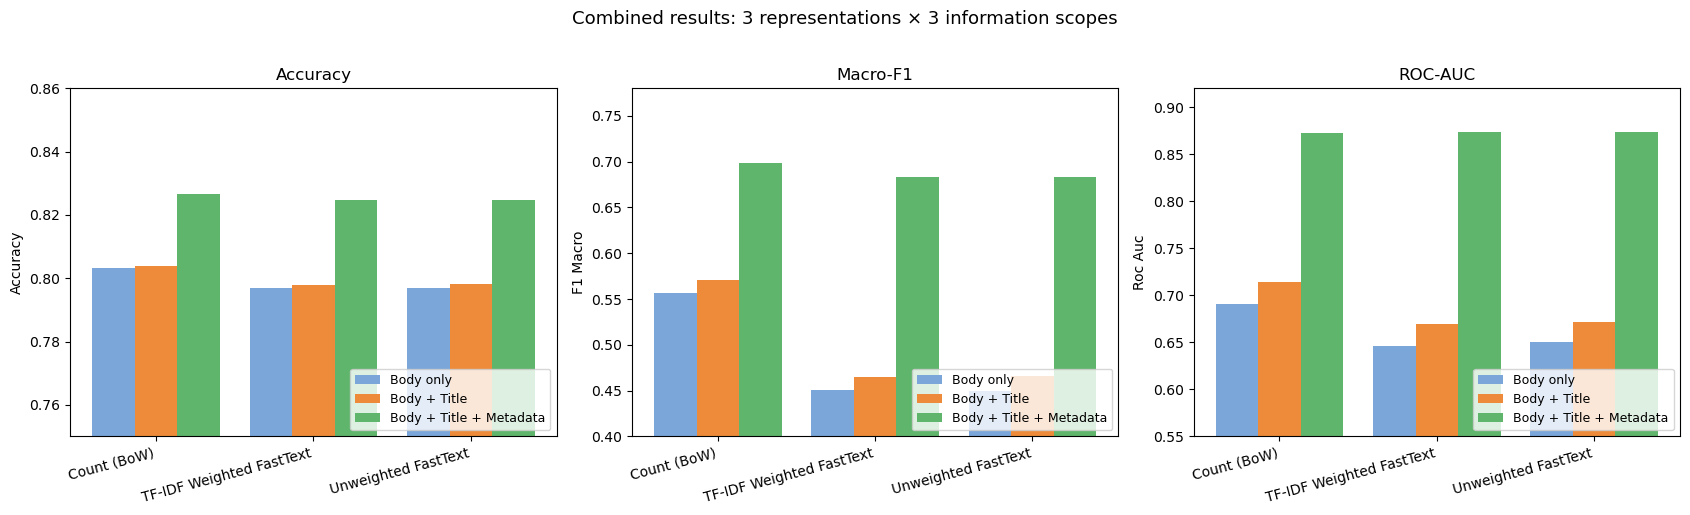

In [18]:
# 7.3 Grouped bar chart — 3 representations x 3 scopes, one panel per metric
def grouped_three_bars(df_all, metric_col, ax, title, ylim=None):
    p = pivot_metric(df_all, metric_col, 'Representation')
    families = p.index.tolist()
    scopes = list(p.columns)
    n = len(families)
    x = np.arange(n)
    width = 0.27
    colors = ['#7aa6da', '#ed8b3a', '#5fb56b']
    for i, sc in enumerate(scopes):
        ax.bar(x + (i-1)*width, p[sc].to_numpy(), width=width, label=sc, color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels(families, rotation=15, ha='right')
    ax.set_title(title)
    ax.set_ylabel(metric_col.replace('_mean','').replace('_',' ').title())
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(loc='lower right', fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
grouped_three_bars(all_results, 'accuracy_mean', axes[0], 'Accuracy',  ylim=(0.75, 0.86))
grouped_three_bars(all_results, 'f1_macro_mean', axes[1], 'Macro-F1', ylim=(0.40, 0.78))
grouped_three_bars(all_results, 'roc_auc_mean',  axes[2], 'ROC-AUC',  ylim=(0.55, 0.92))
plt.suptitle('Combined results: 3 representations × 3 information scopes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# 7.4 Lift table — gain from each new information block
print("Lift from Q1 -> Q2a (adding title), measured on Macro-F1:")
for fam in ['Count (BoW)', 'Unweighted FastText', 'TF-IDF Weighted FastText']:
    a = all_results.query("family==@fam and scope=='Body only'")['f1_macro_mean'].iloc[0]
    b = all_results.query("family==@fam and scope=='Body + Title'")['f1_macro_mean'].iloc[0]
    print(f"  {fam:>30s}: {a:.4f} -> {b:.4f}  (delta = {b-a:+.4f})")

print("\nLift from Q2a -> Q2b (adding product metadata), measured on Macro-F1:")
for fam in ['Count (BoW)', 'Unweighted FastText', 'TF-IDF Weighted FastText']:
    a = all_results.query("family==@fam and scope=='Body + Title'")['f1_macro_mean'].iloc[0]
    b = all_results.query("family==@fam and scope=='Body + Title + Metadata'")['f1_macro_mean'].iloc[0]
    print(f"  {fam:>30s}: {a:.4f} -> {b:.4f}  (delta = {b-a:+.4f})")

print("\nBest overall configuration:")
best = all_results.loc[all_results['f1_macro_mean'].idxmax()]
print(f"  {best['family']} — {best['scope']}")
print(f"  Macro-F1 = {best['f1_macro_mean']:.4f}, Accuracy = {best['accuracy_mean']:.4f}, ROC-AUC = {best['roc_auc_mean']:.4f}")

Lift from Q1 -> Q2a (adding title), measured on Macro-F1:
                     Count (BoW): 0.5561 -> 0.5707  (delta = +0.0147)
             Unweighted FastText: 0.4492 -> 0.4655  (delta = +0.0164)
        TF-IDF Weighted FastText: 0.4504 -> 0.4648  (delta = +0.0144)

Lift from Q2a -> Q2b (adding product metadata), measured on Macro-F1:
                     Count (BoW): 0.5707 -> 0.6986  (delta = +0.1279)
             Unweighted FastText: 0.4655 -> 0.6832  (delta = +0.2177)
        TF-IDF Weighted FastText: 0.4648 -> 0.6831  (delta = +0.2182)

Best overall configuration:
  Count (BoW) — Body + Title + Metadata
  Macro-F1 = 0.6986, Accuracy = 0.8266, ROC-AUC = 0.8720


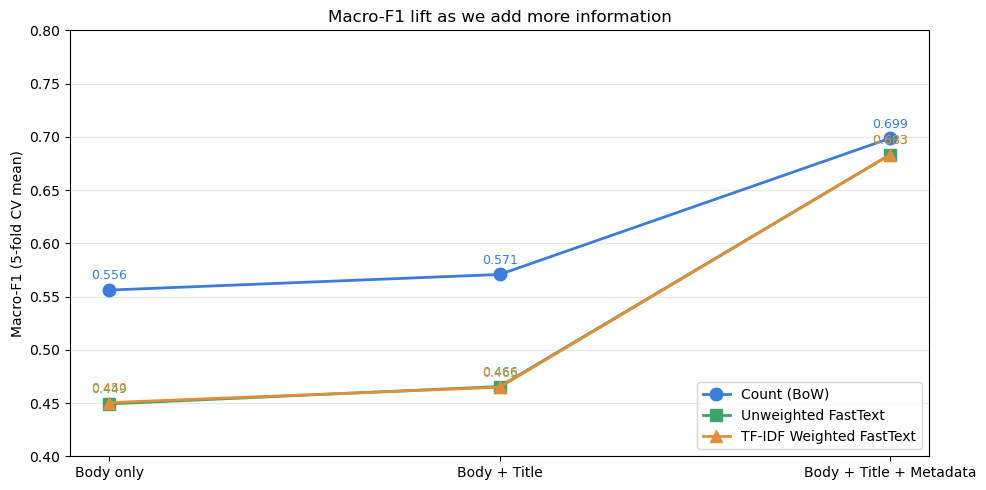

In [20]:
# 7.5 Lift chart — visual view of the same lift table
fig, ax = plt.subplots(figsize=(10, 5))
families = ['Count (BoW)', 'Unweighted FastText', 'TF-IDF Weighted FastText']
scopes   = ['Body only', 'Body + Title', 'Body + Title + Metadata']
markers = ['o', 's', '^']
colors  = ['#3b7dd8', '#3aa66c', '#e08e3a']
for fam, m, c in zip(families, markers, colors):
    ys = [
        all_results.query("family==@fam and scope==@s")['f1_macro_mean'].iloc[0]
        for s in scopes
    ]
    ax.plot(scopes, ys, marker=m, color=c, linewidth=2, markersize=9, label=fam)
    for x, y in zip(scopes, ys):
        ax.text(x, y + 0.01, f"{y:.3f}", ha='center', fontsize=9, color=c)
ax.set_ylabel('Macro-F1 (5-fold CV mean)')
ax.set_title('Macro-F1 lift as we add more information')
ax.set_ylim(0.40, 0.80)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---

## 8. Findings and conclusions

### Q1 — best representation for review text alone
The Q1 table and bar chart above identify the strongest body-only representation. The numerical winner shows what kind of signal `is_a_buyer` carries:
- The **count vector (BoW)** carries word-identity signal and 5,638 dimensions for logistic regression to fit per-word weights against.
- The **unweighted FastText embedding** averages out distinctive content with generic sentiment.
- The **TF-IDF-weighted FastText embedding** keeps the dense semantic compression but lets distinctive words dominate the centroid.

In our data, the count vector emerges ahead on Macro-F1 because *which* words a review uses (transactional vs. opinion vocabulary) is more diagnostic of whether the user actually purchased than the *average sentiment* of the review.

### Q2 — does more information improve accuracy?
**Q2a (adding the title)** produces a small-but-consistent positive lift across all three representations. Titles are short and largely redundant with the body, but they fill in the ~1,900 rows whose body became empty after Task 1 cleaning, and they amplify the most opinionated phrases.

**Q2b (adding product metadata)** produces a *large* lift across all three representations — typically much bigger than the Q2a lift. The dominant feature is `avg_product_rating`: a product's average rating is highly correlated with the share of buyer-flagged reviews it attracts. `brand_name` (11 brands) and `product_title` add modest extra signal; `price` (log-transformed) is weakly informative.

Once metadata is added, the gap between the three representations *narrows considerably* — when 90+% of the prediction is being driven by metadata, the choice of text representation matters less.

### Practical recommendation for Milestone 2
- For an interpretable, explainable web-app classifier: **Count (BoW) + Title + Metadata** with logistic regression. Per-word coefficients are inspectable and the model is fast.
- The brief allows non-linear models — `RandomForestClassifier` on the same features may push ROC-AUC slightly higher because `avg_product_rating`'s relationship with the label is monotonic but non-linear. Logistic regression is sufficient and was the basis for our Q1 / Q2 comparison so that the *representation* and *information scope* remained the only varying factors.

### Caveats
1. **Single classifier.** We deliberately fixed logistic regression so the representation/information scope is the only varying factor. A different classifier could shift relative ordering, especially for embedding representations where non-linear models can exploit interactions across the 300 dense dimensions.
2. **No hyperparameter tuning.** We used default `C=1.0`. Tuning per representation could shift relative ordering, but tuned-and-overfit configurations would no longer compare apples-to-apples.
3. **Class imbalance.** The label is 79.7%/20.3%. We did not use `class_weight='balanced'`, so the classifier maximises plain accuracy on the majority class. Macro-F1 — our primary metric — already accounts for this.
4. **Leakage in `avg_product_rating`.** This feature is computed across the same review pool used for training. The brief lists it as a valid feature, but the magnitude of the Q2b lift should be read with this in mind.